# Census spatial

This notebook prepares an optional, auditable mapping from the published taxi pickup coordinates to the Census polygons. It does not overwrite any files.

The published pickup coordinates are privacy-protected centroids rather than exact trip origins. The reconstructed tract therefore describes the polygon containing the published point, not the true pickup location.

## Scope and decision boundary

The notebook performs read-only steps:

1. validate the taxi and polygon inputs
2. spatially join only the unique published coordinate pairs
3. create a one-row-per-coordinate mapping with quality checks
4. quantify how many trips could receive a reconstructed tract


In [2]:
from pathlib import Path

import duckdb
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from run_config import PATHS, RUN_MODE

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 100)

# Optional output only
WRITE_MAPPING = False
MAPPING_OUTPUT_PATH = (
    Path(PATHS.gold_taxi_trips).parent
    / "census_pickup_coordinate_mapping.parquet"
)

TRIPS_PATH = Path(PATHS.gold_taxi_trips)
CENSUS_POLYGONS_PATH = Path(PATHS.silver_census_tracts)

print(f"Run mode: {RUN_MODE}")
print(f"Trips: {TRIPS_PATH}")
print(f"Census polygons: {CENSUS_POLYGONS_PATH}")
print(f"Write mapping: {WRITE_MAPPING}")
print(f"Optional output: {MAPPING_OUTPUT_PATH}")

Run mode: full
Trips: /Users/moritz/Documents/Master Studium/Advanced Analytics and Application/assignment/Group-3-AAA/data/full/processed_data/gold_taxi.parquet
Census polygons: /Users/moritz/Documents/Master Studium/Advanced Analytics and Application/assignment/Group-3-AAA/data/full/processed_data/silver_census_tracts.geoparquet
Write mapping: False
Optional output: /Users/moritz/Documents/Master Studium/Advanced Analytics and Application/assignment/Group-3-AAA/data/full/processed_data/census_pickup_coordinate_mapping.parquet


## Load and validate the inputs

Census identifiers are normalized as 11-character strings for comparison and output. This preserves leading zeros and avoids accidental floating-point identifiers

In [3]:
for required_path in (TRIPS_PATH, CENSUS_POLYGONS_PATH):
    if not required_path.exists():
        raise FileNotFoundError(required_path)

con = duckdb.connect()
con.execute("SET threads = 4")
con.execute(
    f"CREATE OR REPLACE VIEW trips AS "
    f"SELECT * FROM read_parquet('{TRIPS_PATH.as_posix()}')"
)

required_trip_columns = {
    "pickup_centroid_latitude",
    "pickup_centroid_longitude",
    "pickup_census_tract",
}
trip_columns = set(con.sql("DESCRIBE trips").df()["column_name"])
missing_trip_columns = required_trip_columns - trip_columns
if missing_trip_columns:
    raise ValueError(f"Taxi input is missing columns: {sorted(missing_trip_columns)}")

census_polygons = gpd.read_parquet(CENSUS_POLYGONS_PATH)
if "CENSUS_T_1" not in census_polygons.columns:
    raise ValueError("Census polygons are missing CENSUS_T_1")
if census_polygons.crs is None:
    raise ValueError("Census polygons must have a defined CRS")
if census_polygons.geometry.isna().any():
    raise ValueError("Census polygons contain missing geometries")
if not census_polygons.geometry.is_valid.all():
    raise ValueError("Census polygons contain invalid geometries")

census_polygons = census_polygons[["CENSUS_T_1", "geometry"]].copy()
census_polygons["census_tract_spatial"] = (
    pd.to_numeric(census_polygons["CENSUS_T_1"], errors="raise")
    .astype("int64")
    .astype("string")
    .str.zfill(11)
)
if census_polygons["census_tract_spatial"].duplicated().any():
    raise ValueError("Census polygon IDs are not unique")
census_polygons = census_polygons.drop(columns="CENSUS_T_1")

polygon_id_frame = census_polygons[["census_tract_spatial"]].rename(
    columns={"census_tract_spatial": "published_census_id"}
)
con.register("valid_polygon_ids", polygon_id_frame)

trip_count = con.sql("SELECT COUNT(*) FROM trips").fetchone()[0]
print(f"Trips: {trip_count:,}")
print(f"Census polygons: {len(census_polygons):,}")
print(f"Polygon CRS: {census_polygons.crs}")

Trips: 13,387,586
Census polygons: 878
Polygon CRS: {"$schema": "https://proj.org/schemas/v0.7/projjson.schema.json", "type": "GeographicCRS", "name": "WGS 84", "datum_ensemble": {"name": "World Geodetic System 1984 ensemble", "members": [{"name": "World Geodetic System 1984 (Transit)"}, {"name": "World Geodetic System 1984 (G730)"}, {"name": "World Geodetic System 1984 (G873)"}, {"name": "World Geodetic System 1984 (G1150)"}, {"name": "World Geodetic System 1984 (G1674)"}, {"name": "World Geodetic System 1984 (G1762)"}, {"name": "World Geodetic System 1984 (G2139)"}, {"name": "World Geodetic System 1984 (G2296)"}], "ellipsoid": {"name": "WGS 84", "semi_major_axis": 6378137, "inverse_flattening": 298.257223563}, "accuracy": "2.0", "id": {"authority": "EPSG", "code": 6326}}, "coordinate_system": {"subtype": "ellipsoidal", "axis": [{"name": "Geodetic latitude", "abbreviation": "Lat", "direction": "north", "unit": "degree"}, {"name": "Geodetic longitude", "abbreviation": "Lon", "direction

## Extract the unique published coordinates

The spatial join is performed once per unique latitude/longitude pair, not once per trip. Trip counts are retained as weights for later coverage summaries. Rows without published coordinates cannot be spatially reconstructed and are counted separately.

In [4]:
source_coverage = con.sql("""
    SELECT
        COUNT(*) AS all_trips,
        COUNT(*) FILTER (
            WHERE pickup_centroid_latitude IS NOT NULL
              AND pickup_centroid_longitude IS NOT NULL
        ) AS trips_with_coordinates,
        COUNT(*) FILTER (WHERE pickup_census_tract IS NOT NULL)
            AS trips_with_published_census_id
    FROM trips
""").df()

unique_coordinates = con.sql("""
    SELECT
        pickup_centroid_latitude AS latitude,
        pickup_centroid_longitude AS longitude,
        COUNT(*) AS trips
    FROM trips
    WHERE pickup_centroid_latitude IS NOT NULL
      AND pickup_centroid_longitude IS NOT NULL
    GROUP BY 1, 2
    ORDER BY 1, 2
""").df()

if unique_coordinates.duplicated(["latitude", "longitude"]).any():
    raise AssertionError("Coordinate extraction did not produce a unique key")
if int(unique_coordinates["trips"].sum()) != int(source_coverage.at[0, "trips_with_coordinates"]):
    raise AssertionError("Coordinate weights do not add up to the source coverage")

display(source_coverage)
print(f"Unique published coordinate pairs: {len(unique_coordinates):,}")
display(unique_coordinates.sort_values("trips", ascending=False).head(10))

,all_trips,trips_with_coordinates,trips_with_published_census_id
0,13387586,13387586,6050103


Unique published coordinate pairs: 544


,latitude,longitude,trips
483,41.980264,-87.913625,1514656
477,41.979071,-87.903040,1345178
303,41.899602,-87.633308,1337871
264,41.878866,-87.625192,660733
268,41.880994,-87.632746,647897
270,41.884987,-87.620993,636255
256,41.874005,-87.663518,553186
267,41.879255,-87.642649,510256
402,41.944227,-87.655998,419675
288,41.892508,-87.626215,354845


## Reconstruct the containing Census tract

a published point must lie strictly inside one polygon. Boundary and outside cases remain unresolved rather than being assigned silently. Any duplicate spatial matches stop the notebook because the mapping must have exactly one row per coordinate.

In [5]:
published_points = gpd.GeoDataFrame(
    unique_coordinates.copy(),
    geometry=gpd.points_from_xy(
        unique_coordinates["longitude"],
        unique_coordinates["latitude"],
    ),
    crs="EPSG:4326",
)
if published_points.crs != census_polygons.crs:
    published_points = published_points.to_crs(census_polygons.crs)

spatial_join = gpd.sjoin(
    published_points,
    census_polygons[["census_tract_spatial", "geometry"]],
    how="left",
    predicate="within",
).drop(columns="index_right")

duplicate_coordinate_matches = spatial_join.duplicated(
    ["latitude", "longitude"], keep=False
)
if duplicate_coordinate_matches.any():
    display(spatial_join.loc[duplicate_coordinate_matches].sort_values(["latitude", "longitude"]))
    raise ValueError("At least one coordinate matched multiple Census polygons")

coordinate_mapping = (
    spatial_join[["latitude", "longitude", "census_tract_spatial", "trips"]]
    .rename(columns={"census_tract_spatial": "pickup_census_tract_spatial"})
    .sort_values(["latitude", "longitude"])
    .reset_index(drop=True)
)
coordinate_mapping["mapping_status"] = np.where(
    coordinate_mapping["pickup_census_tract_spatial"].notna(),
    "within census polygon",
    "outside or on polygon boundary",
)

assert len(coordinate_mapping) == len(unique_coordinates)
assert not coordinate_mapping.duplicated(["latitude", "longitude"]).any()

mapping_summary = (
    coordinate_mapping.groupby("mapping_status", dropna=False)
    .agg(unique_coordinates=("latitude", "size"), trips=("trips", "sum"))
    .reset_index()
)
mapping_summary["trip_share_with_coordinates_pct"] = (
    100 * mapping_summary["trips"] / mapping_summary["trips"].sum()
)
display(mapping_summary.round(3))

,mapping_status,unique_coordinates,trips,trip_share_with_coordinates_pct
0,within census polygon,544,13387586,100.0


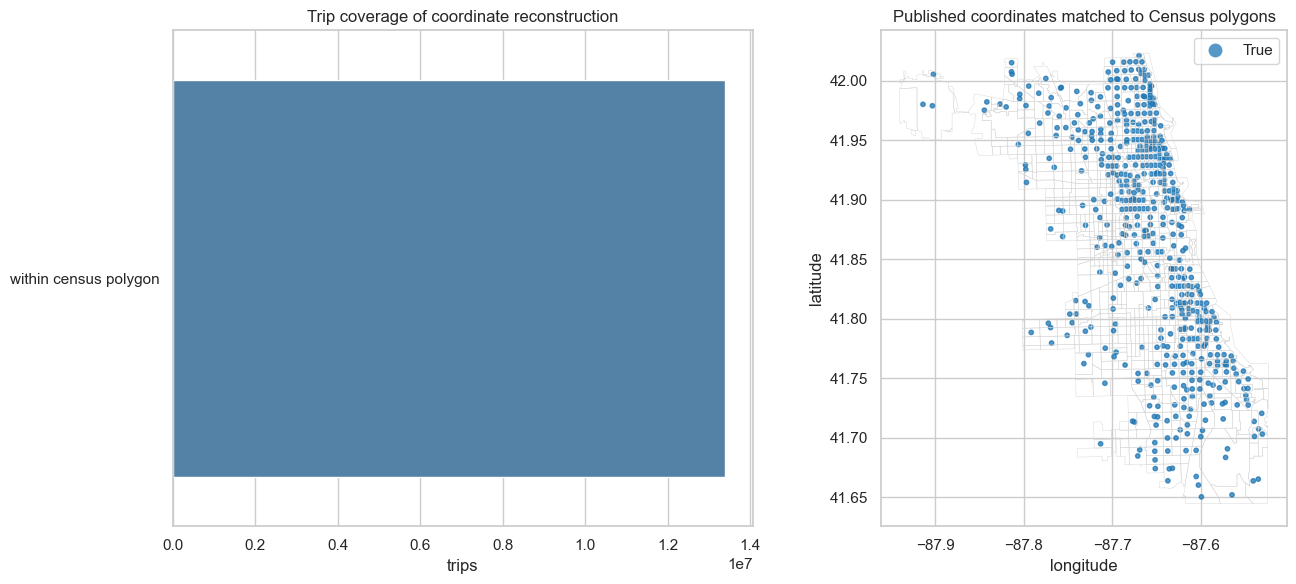

In [6]:
mapping_plot = mapping_summary.copy()
mapping_plot["display_status"] = mapping_plot["mapping_status"].replace({
    "within census polygon": "Matched to a Census polygon",
    "outside or on polygon boundary": "Unmatched or on a boundary",
})
mapping_plot["trip_share_pct"] = 100 * mapping_plot["trips"] / mapping_plot["trips"].sum()

fig, ax = plt.subplots(figsize=(9, 3.8), layout="constrained")
sns.barplot(
    data=mapping_plot,
    y="display_status",
    x="trips",
    color="#4C78A8",
    ax=ax,
)
ax.set(
    title="Coverage of the coordinate-based Census reconstruction",
    xlabel="Trips represented by published coordinates",
    ylabel="",
)
ax.ticklabel_format(axis="x", style="plain")
ax.margins(x=0.18)
for container, share in zip(ax.containers, [mapping_plot["trip_share_pct"].to_numpy()]):
    labels = [f"{value / 1_000_000:.2f}M ({pct:.2f}%)" for value, pct in zip(container.datavalues, share)]
    ax.bar_label(container, labels=labels, padding=6, fontsize=10)
sns.despine(ax=ax, left=True)
plt.show()

map_points = spatial_join.copy()
map_points["match_status"] = np.where(
    map_points["census_tract_spatial"].notna(),
    "Matched",
    "Unmatched",
)
point_colors = {"Matched": "#2A9D8F", "Unmatched": "#E76F51"}

fig, ax = plt.subplots(figsize=(7.5, 7.5), layout="constrained")
census_polygons.boundary.plot(ax=ax, color="#B8B8B8", linewidth=0.35)
for status, frame in map_points.groupby("match_status", sort=False):
    frame.plot(
        ax=ax,
        color=point_colors[status],
        markersize=14,
        alpha=0.75,
        label=f"{status} ({len(frame):,} coordinates)",
    )
ax.set(
    title="Published pickup coordinates and Census polygons",
    xlabel="Longitude",
    ylabel="Latitude",
)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.08), frameon=False, ncol=2)
plt.show()

## Audit source IDs against the reconstructed IDs

The mapping itself is keyed only by the published coordinate pair. For the audit, it is joined back to the trip table and the original source ID is compared with the reconstructed polygon ID. This preserves the distinction between an exact agreement, a likely Census-vintage mismatch and a missing source ID.

In [7]:
mapping_for_join = coordinate_mapping[[
    "latitude",
    "longitude",
    "pickup_census_tract_spatial",
]].copy()
con.register("coordinate_mapping", mapping_for_join)

trip_audit = con.sql("""
    WITH classified AS (
        SELECT
            CASE
                WHEN t.pickup_centroid_latitude IS NULL
                  OR t.pickup_centroid_longitude IS NULL
                    THEN 'published coordinates missing'
                WHEN m.pickup_census_tract_spatial IS NULL
                    THEN 'outside or on polygon boundary'
                WHEN t.pickup_census_tract IS NULL
                    THEN 'source ID missing; reconstructed'
                WHEN lpad(CAST(CAST(t.pickup_census_tract AS BIGINT) AS VARCHAR), 11, '0')
                     = m.pickup_census_tract_spatial
                    THEN 'exact source/spatial match'
                ELSE 'source ID differs; reconstructed'
            END AS quality_flag
        FROM trips t
        LEFT JOIN coordinate_mapping m
          ON t.pickup_centroid_latitude = m.latitude
         AND t.pickup_centroid_longitude = m.longitude
    )
    SELECT quality_flag, COUNT(*) AS trips
    FROM classified
    GROUP BY quality_flag
    ORDER BY trips DESC
""").df()
trip_audit["trip_share_pct"] = 100 * trip_audit["trips"] / trip_audit["trips"].sum()

if int(trip_audit["trips"].sum()) != trip_count:
    raise AssertionError("Trip audit does not add up to the source row count")
display(trip_audit.round(3))

,quality_flag,trips,trip_share_pct
0,source ID missing; reconstructed,7337483,54.808
1,source ID differs; reconstructed,3219393,24.048
2,exact source/spatial match,2830710,21.144


In [8]:
coverage_comparison = con.sql("""
    SELECT
        COUNT(*) AS all_trips,
        COUNT(*) FILTER (WHERE t.pickup_census_tract IS NOT NULL)
            AS published_id_present,
        COUNT(*) FILTER (WHERE p.published_census_id IS NOT NULL)
            AS direct_id_match_to_polygon_table,
        COUNT(*) FILTER (WHERE m.pickup_census_tract_spatial IS NOT NULL)
            AS spatial_reconstruction_available
    FROM trips t
    LEFT JOIN valid_polygon_ids p
      ON lpad(CAST(CAST(t.pickup_census_tract AS BIGINT) AS VARCHAR), 11, '0')
       = p.published_census_id
    LEFT JOIN coordinate_mapping m
      ON t.pickup_centroid_latitude = m.latitude
     AND t.pickup_centroid_longitude = m.longitude
""").df()

for column in coverage_comparison.columns[1:]:
    coverage_comparison[f"{column}_pct_all"] = (
        100 * coverage_comparison[column] / coverage_comparison["all_trips"]
    )
display(coverage_comparison.round(3))

,all_trips,published_id_present,direct_id_match_to_polygon_table,spatial_reconstruction_available,published_id_present_pct_all,direct_id_match_to_polygon_table_pct_all,spatial_reconstruction_available_pct_all
0,13387586,6050103,2830710,13387586,45.192,21.144,100.0


## Compare old and reconstructed Census zero shares

The existing Census Gold files provide the complete grids. For a like-for-like comparison, the reconstructed demand is aggregated in memory and joined to exactly those grids

A zero therefore means that a grid row has no trip under the respective assignment rule. The comparison separates the effect of the faulty direct ID join from the remaining genuine and privacy-induced spatio-temporal sparsity.

,time_unit,old_zero_pct,reconstructed_zero_pct,reduction_percentage_points,panel_rows,reconstructed_trips_in_panel
0,1h,98.841,93.413,5.428,17933150,13387586
1,2h,98.565,91.808,6.757,8967014,13387586
2,4h,98.161,90.128,8.032,4483946,13387586


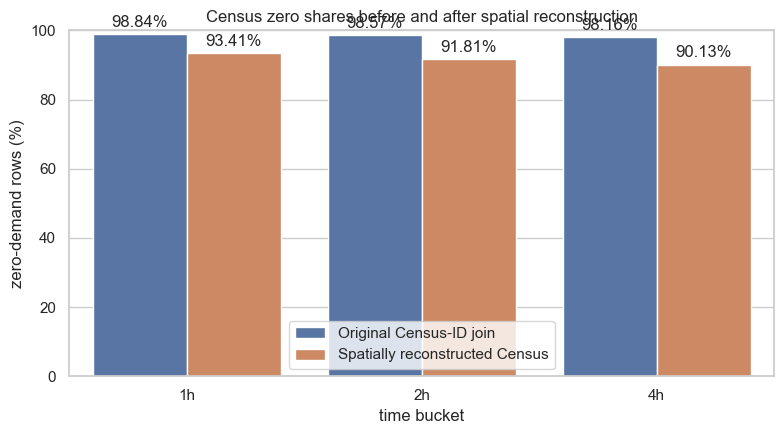

In [9]:
census_gold_paths = {
    "1h": Path(PATHS.gold_1h_demand_census_tracts),
    "2h": Path(PATHS.gold_2h_demand_census_tracts),
    "4h": Path(PATHS.gold_4h_demand_census_tracts),
}
duckdb_intervals = {"1h": "1 hour", "2h": "2 hours", "4h": "4 hours"}

zero_share_rows = []
for time_unit, grid_path in census_gold_paths.items():
    if not grid_path.exists():
        raise FileNotFoundError(grid_path)

    escaped_grid_path = grid_path.as_posix().replace("'", "''")
    interval = duckdb_intervals[time_unit]
    result = con.sql(f"""
        WITH grid AS (
            SELECT
                datetime_hour,
                lpad(
                    CAST(CAST(census_tract AS BIGINT) AS VARCHAR),
                    11,
                    '0'
                ) AS census_tract,
                trip_count AS old_trip_count
            FROM read_parquet('{escaped_grid_path}')
        ),
        reconstructed_demand AS (
            SELECT
                time_bucket(
                    INTERVAL '{interval}',
                    CAST(t.trip_start_timestamp AS TIMESTAMP)
                ) AS datetime_hour,
                m.pickup_census_tract_spatial AS census_tract,
                COUNT(*) AS trip_count
            FROM trips t
            JOIN coordinate_mapping m
              ON t.pickup_centroid_latitude = m.latitude
             AND t.pickup_centroid_longitude = m.longitude
            WHERE t.trip_start_timestamp IS NOT NULL
              AND m.pickup_census_tract_spatial IS NOT NULL
            GROUP BY 1, 2
        )
        SELECT
            COUNT(*) AS panel_rows,
            SUM(CASE WHEN g.old_trip_count = 0 THEN 1 ELSE 0 END)
                AS old_zero_rows,
            SUM(CASE WHEN d.trip_count IS NULL THEN 1 ELSE 0 END)
                AS reconstructed_zero_rows,
            COUNT(d.trip_count) AS reconstructed_positive_rows,
            SUM(COALESCE(d.trip_count, 0)) AS reconstructed_trips_in_panel
        FROM grid g
        LEFT JOIN reconstructed_demand d
          ON g.datetime_hour = d.datetime_hour
         AND g.census_tract = d.census_tract
    """).df().iloc[0]

    old_zero_pct = 100 * result["old_zero_rows"] / result["panel_rows"]
    reconstructed_zero_pct = (
        100 * result["reconstructed_zero_rows"] / result["panel_rows"]
    )
    zero_share_rows.append({
        "time_unit": time_unit,
        "panel_rows": int(result["panel_rows"]),
        "old_zero_rows": int(result["old_zero_rows"]),
        "old_zero_pct": old_zero_pct,
        "reconstructed_zero_rows": int(result["reconstructed_zero_rows"]),
        "reconstructed_zero_pct": reconstructed_zero_pct,
        "reduction_percentage_points": old_zero_pct - reconstructed_zero_pct,
        "reconstructed_positive_rows": int(result["reconstructed_positive_rows"]),
        "reconstructed_trips_in_panel": int(result["reconstructed_trips_in_panel"]),
    })

zero_share_comparison = pd.DataFrame(zero_share_rows)
display(
    zero_share_comparison[[
        "time_unit",
        "old_zero_pct",
        "reconstructed_zero_pct",
        "reduction_percentage_points",
        "panel_rows",
        "reconstructed_trips_in_panel",
    ]].round(3)
)

comparison_panels = [
    ("old_zero_pct", "Original Census-ID join", "#9E9E9E"),
    ("reconstructed_zero_pct", "Spatially reconstructed Census", "#4C78A8"),
]

fig, axes = plt.subplots(
    1,
    2,
    figsize=(10.5, 5.2),
    sharey=True,
    layout="constrained",
)
for ax, (value_col, panel_title, color) in zip(axes, comparison_panels):
    sns.barplot(
        data=zero_share_comparison,
        x="time_unit",
        y=value_col,
        color=color,
        ax=ax,
    )
    ax.set(
        title=panel_title,
        xlabel="Time bucket",
        ylabel="Zero-demand rows (%)" if ax is axes[0] else "",
        ylim=(0, 106),
    )
    ax.set_title(panel_title, pad=14)
    ax.bar_label(ax.containers[0], fmt="%.2f%%", padding=4, fontsize=10)
    ax.grid(axis="x", visible=False)
    sns.despine(ax=ax, left=ax is not axes[0])

plt.show()

### Interpretation

The spatial reconstruction should reduce the zero share because trips with missing or incompatible published Census IDs can be assigned to the polygon containing their published coordinate. A high remaining zero share is not automatically another join error: it also reflects the large number of Census tracts, fine time buckets, concentrated taxi demand and the limited set of published privacy centroids.

The reconstructed result is therefore suitable as a sensitivity analysis and a more defensible Census benchmark, but it must not be interpreted as street-level spatial recovery.